In [1]:
from datasets import load_dataset
from collections import Counter
import numpy as np
from word2vec import SG_Word2Vec

# Prep the dataset

In [2]:
dataset = load_dataset("wikitext", "wikitext-103-v1")

def flatten(text_list):
    tokens = []
    
    for line in text_list:
        line = line.lower()
        if line.strip() == "":
            continue
        tokens.extend(line.split())
    
    return tokens

tokens = flatten(dataset['train']['text']) + flatten(dataset['validation']['text']) + flatten(dataset['test']['text'])

In [3]:
counts = Counter(tokens)
min_count = 5

vocab = {token: i for i, token in enumerate(token for (token, count) in counts.items() if count >= min_count)}

In [4]:
def tokenize(tokens, vocab):
    return np.array([vocab[token] for token in tokens if token in vocab])
    
token_ids = tokenize(tokens, vocab)

vocab_size = np.max(token_ids) + 1

del tokens

In [5]:
def get_relative_freqs(tokens):
    counts = Counter(tokens)
    freq = np.zeros(vocab_size)

    for token, count in counts.items():
        freq[token] = count / len(tokens)
    
    return freq

In [6]:
neg_dist = get_relative_freqs(token_ids) ** 0.75
neg_dist /= neg_dist.sum()

# Training

In [7]:
def batch_generator(tokens, batch_size, window_size, num_neg_samples):

    while True:
        centers = []
        positive_contexts = []

        while len(centers) < batch_size:
            i = np.random.randint(window_size, len(tokens)-window_size)
            center = tokens[i]

            offset = 0
            while offset == 0:
                offset = np.random.randint(-window_size, window_size+1)
                
            positive_context = tokens[i + offset]

            centers.append(center)
            positive_contexts.append(positive_context)

        negative_samples = np.random.choice(
            vocab_size,
            size=(batch_size, num_neg_samples),
            p=neg_dist
        )

        yield (
            np.expand_dims(np.array(centers, dtype=int), axis=-1),
            np.expand_dims(np.array(positive_contexts, dtype=int), axis=-1),
            negative_samples
        )

In [ ]:
def train(model, tokens, batch_size, window_size, num_neg_samples, steps, lr):
    total_loss = 0
    step = 0
    for centers, positive_contexts, negative_samples in batch_generator(tokens, batch_size, window_size, num_neg_samples):
        total_loss += model.training_step(centers, positive_contexts, negative_samples, lr)
        step += 1
        
        if step > steps:
            break
    
    return total_loss / steps

In [9]:
model = SG_Word2Vec(vocab_size, 300)

batch_size = 256
window_size = 5
num_neg_samples = 20

max_epochs = 200

patience = 8

epochs_without_improvement = 0
best_loss = float('inf')

steps_per_epoch = 250
validate_evaluate_steps = 50
test_evaluate_steps = 500

lr = 0.005

for epoch in range(max_epochs):
    loss = train(model, token_ids, batch_size, window_size, num_neg_samples, steps_per_epoch, lr)

    if loss < best_loss:
        best_loss = loss
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    
    if epochs_without_improvement > patience:
        print("Early stopping")
        break

    print(f"epoch {epoch+1} | loss {loss:.4f}")

epoch 1 | loss 14.1945
epoch 2 | loss 12.5005
epoch 3 | loss 11.2784
epoch 4 | loss 10.5187
epoch 5 | loss 9.9423
epoch 6 | loss 9.4772
epoch 7 | loss 9.1309
epoch 8 | loss 8.8192
epoch 9 | loss 8.5275
epoch 10 | loss 8.2984
epoch 11 | loss 8.1031
epoch 12 | loss 7.8768
epoch 13 | loss 7.7043
epoch 14 | loss 7.5464
epoch 15 | loss 7.4089
epoch 16 | loss 7.2841
epoch 17 | loss 7.1403
epoch 18 | loss 7.0098
epoch 19 | loss 6.9093
epoch 20 | loss 6.8154
epoch 21 | loss 6.7138
epoch 22 | loss 6.6125
epoch 23 | loss 6.5502
epoch 24 | loss 6.4636
epoch 25 | loss 6.3919
epoch 26 | loss 6.3156
epoch 27 | loss 6.2548
epoch 28 | loss 6.2067
epoch 29 | loss 6.1665
epoch 30 | loss 6.1095
epoch 31 | loss 6.0466
epoch 32 | loss 5.9872
epoch 33 | loss 5.9619
epoch 34 | loss 5.8958
epoch 35 | loss 5.8610
epoch 36 | loss 5.8403
epoch 37 | loss 5.7606
epoch 38 | loss 5.7361
epoch 39 | loss 5.7148
epoch 40 | loss 5.6808
epoch 41 | loss 5.6329
epoch 42 | loss 5.6015
epoch 43 | loss 5.5750
epoch 44 | loss 

# PCA Visualisation

In [10]:
def pca(X, n_components):
    X_mean = np.mean(X, axis=0)
    X_centered = X - X_mean

    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

    principal_components = Vt[:n_components, :].T

    X_reduced = X_centered @ principal_components

    return X_reduced

In [11]:
norms = np.linalg.norm(model.input_embeddings, axis=1, keepdims=True)
embeddings_normalised = model.input_embeddings / norms

projected_embeddings = pca(embeddings_normalised, 2)

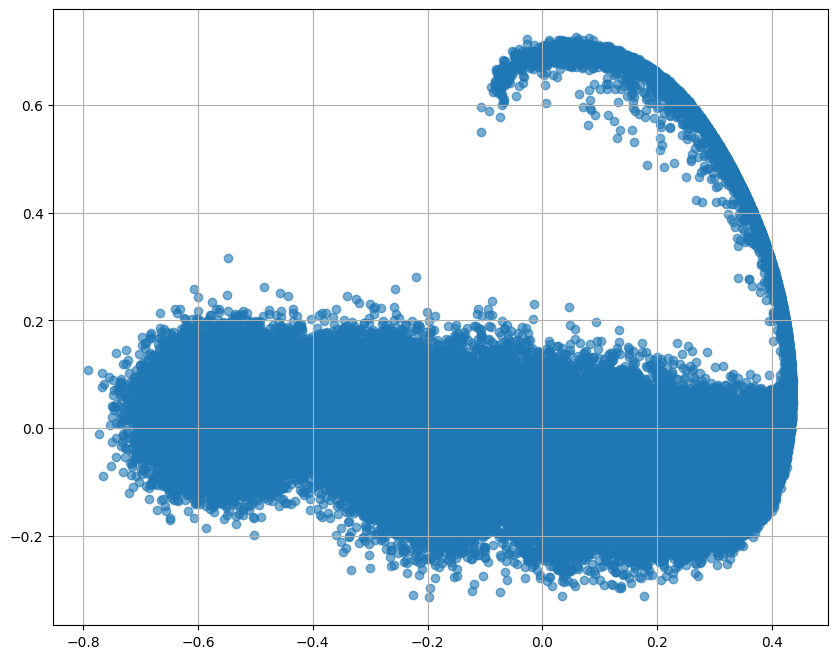

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(projected_embeddings[:, 0], projected_embeddings[:, 1], alpha=0.6)

plt.grid(True)
plt.show()